In [2]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jax
import jax.random as jr

In [3]:
from checkpoint import load_latest
from train_mat import F_pred_nomat, _build_model, F_true
from pathlib import Path

ckpt_dir = Path.cwd() / "checkpoints"
F_net, _ = load_latest(ckpt_dir, _build_model)

loading latest checkpoint from /scratch/ab13780/riemaNN/innt/riemann/checkpoints/F_net_010000.msgpack


In [24]:
from evaluate import draw_small_jumps
from train_mat import RESTRICTED_BOUNDS

key = jr.PRNGKey(0)
x_batch = draw_small_jumps(key, 1_000_000, RESTRICTED_BOUNDS, jump_max_rel=1e-3)
# print(x[:10])

flux_true = jax.vmap(F_true)(x_batch)
flux_pred = jax.vmap(lambda r: F_pred_nomat(F_net, r))(x_batch)

print(flux_true.shape, flux_pred.shape)

(1000000, 3) (1000000, 3)


In [25]:
eps = 1e-2
rel_err = jnp.abs(flux_pred - flux_true) / (jnp.abs(flux_true) + eps)

print(jnp.max(rel_err, axis=0))
print(jnp.argmax(rel_err, axis=0))

def print_values(x):
    print('t:', x[0])
    print('delta rho:', 10.**x[4] - 10.**x[1])
    print('delta u:', x[5] - x[2])
    print('delta p:', 10.**x[6] - 10.**x[3])

print()
for i in jnp.argmax(rel_err, axis=0):
    print_values(x_batch[i])
    print('')

[9.27827351e-04 1.10098313e-06 6.75723595e-05]
[220755 207406 972190]

t: 0.6633245111205135
delta rho: -0.0012212671595388525
delta u: 4.60438662485004e-07
delta p: 0.001122141562898582

t: 0.9588407580569307
delta rho: 0.0012328760736868283
delta u: 3.0907911465170856e-05
delta p: -0.0007843152322110081

t: 0.18926984007866943
delta rho: -0.0011438769748208788
delta u: -1.2066313949854642e-07
delta p: 0.0008519522663206214



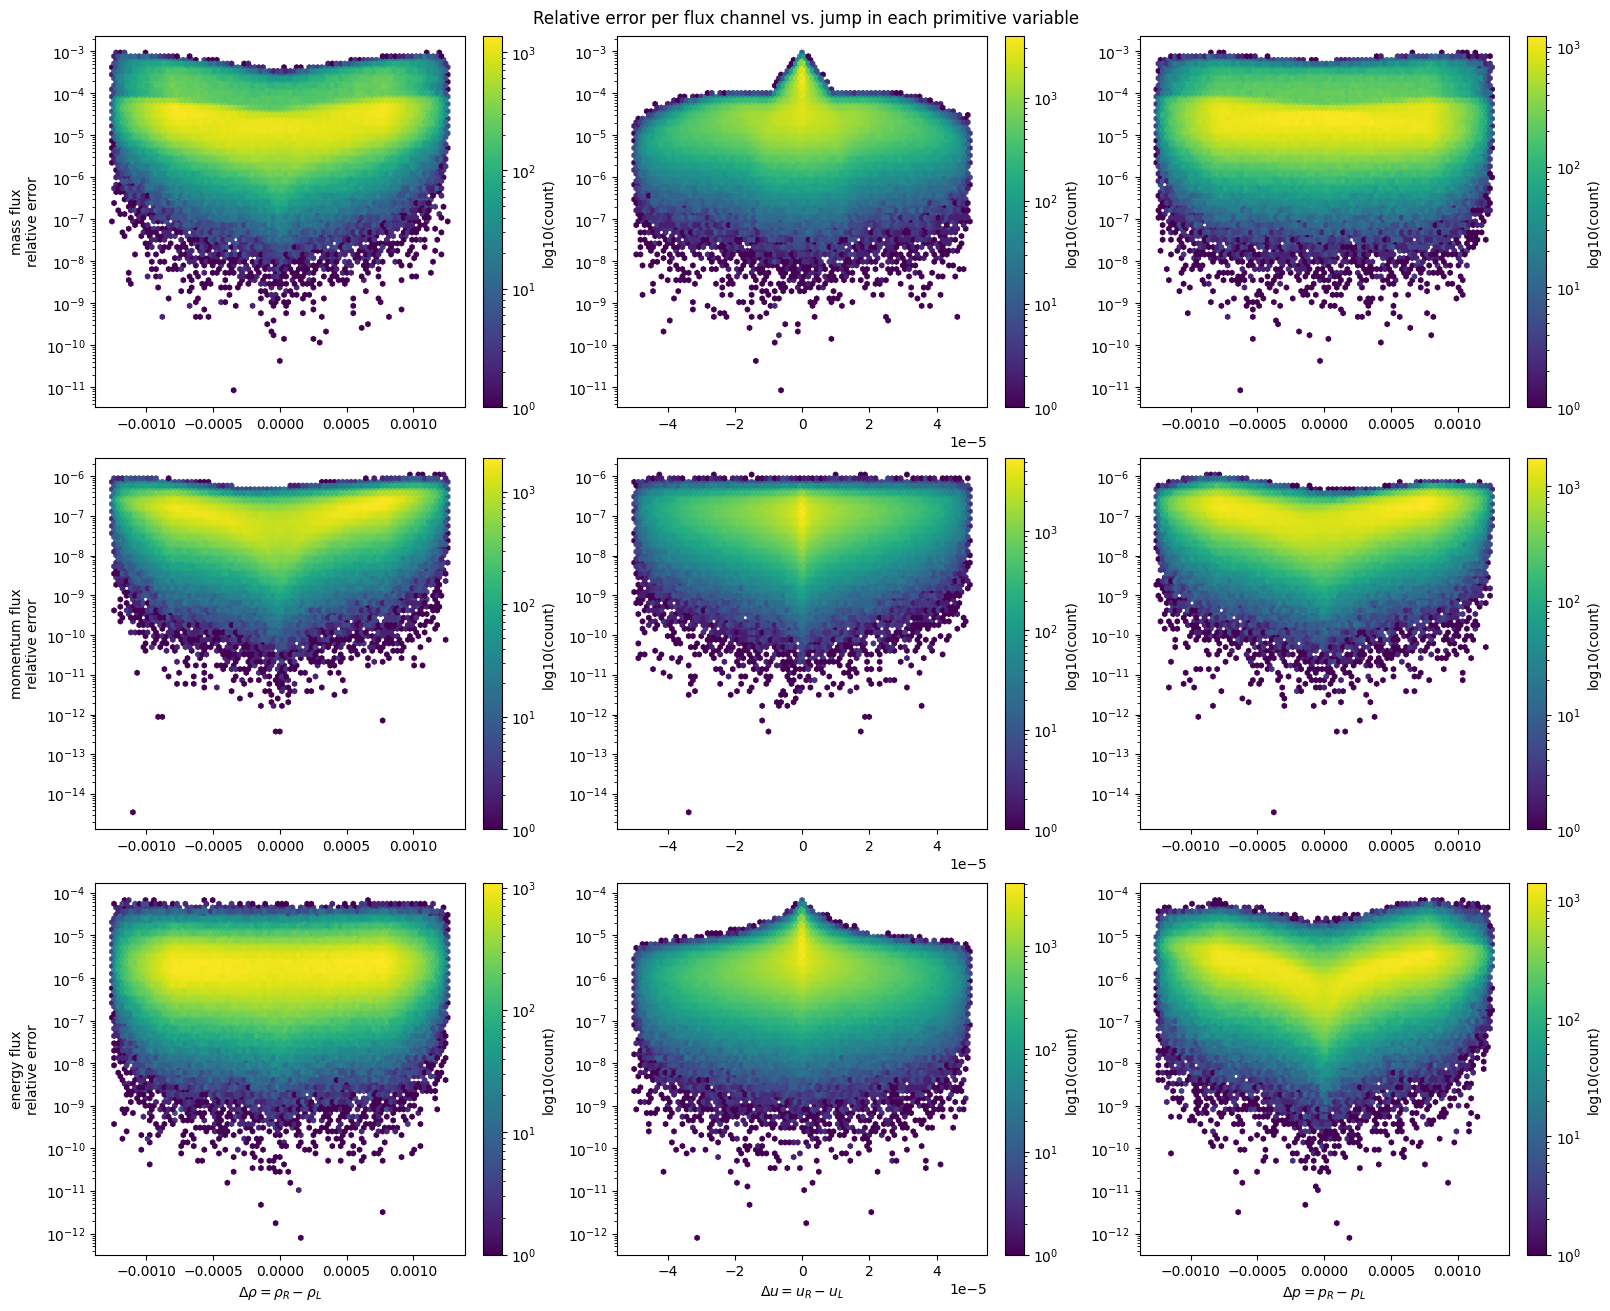

In [26]:
# Recover primitive states from x_batch columns:
# [t, log10_rhoL, uL, log10_pL, log10_rhoR, uR, log10_pR]
rhoL, uL, pL = 10.0 ** x_batch[:, 1], x_batch[:, 2], 10.0 ** x_batch[:, 3]
rhoR, uR, pR = 10.0 ** x_batch[:, 4], x_batch[:, 5], 10.0 ** x_batch[:, 6]

delta_rho = rhoR - rhoL
delta_u = uR - uL
delta_p = pR - pL

deltas = [
    (r"$\Delta\rho = \rho_R - \rho_L$", delta_rho),
    (r"$\Delta u = u_R - u_L$", delta_u),
    (r"$\Delta p = p_R - p_L$", delta_p),
]
channel_labels = ("mass flux", "momentum flux", "energy flux")

# 3x3 grid: rows = flux channel, columns = jump variable.
fig, axes = plt.subplots(3, 3, figsize=(16, 13), constrained_layout=True)
for row, channel in enumerate(channel_labels):
    err = rel_err[:, row]
    for col, (label, d) in enumerate(deltas):
        ax = axes[row, col]
        hb = ax.hexbin(
            jnp.asarray(d),
            jnp.asarray(err),
            gridsize=80,
            yscale="log",
            bins="log",
            mincnt=1,
            cmap="viridis",
        )
        if row == 2:
            ax.set_xlabel(label)
        if col == 0:
            ax.set_ylabel(f"{channel}\nrelative error")
        fig.colorbar(hb, ax=ax, label="log10(count)")

fig.suptitle(r"Relative error per flux channel vs. jump in each primitive variable")
plt.show()

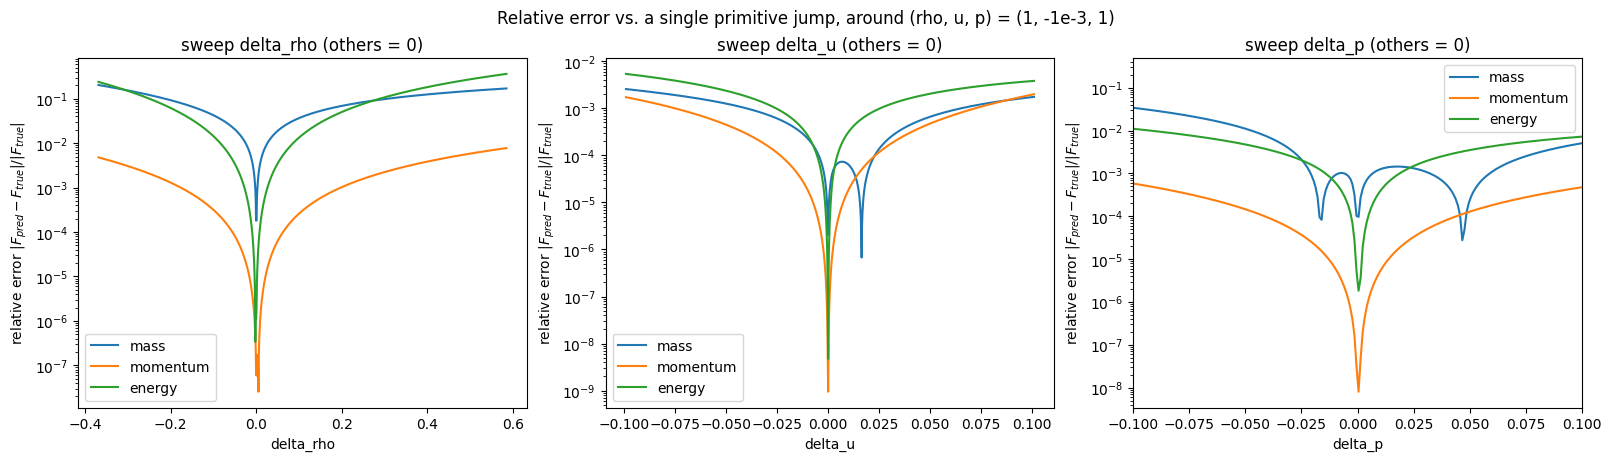

In [21]:
# 1D sweeps around the base state (rho, u, p) = (1, 0, 1): vary one jump at a
# time, holding the other two at zero. Left state is fixed at the base; the
# right state is base + delta in a single primitive variable.
t_fix = 0.5
N = 1000
eps = 1e-2

# log10 of the base state and per-variable right-state sweep ranges
log10_rho0, u0, log10_p0 = 0.0, -1e-3, 0.0
sweeps = {
    "delta_rho": dict(col=4, vals=jnp.linspace(-0.2, 0.2, N), log=True,  base=log10_rho0),
    "delta_u":   dict(col=5, vals=jnp.linspace(-0.1, 0.1, N), log=False, base=u0),
    "delta_p":   dict(col=6, vals=jnp.linspace(-0.2, 0.2, N), log=True,  base=log10_p0),
}

channel_labels = ("mass", "momentum", "energy")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for ax, (name, cfg) in zip(axes, sweeps.items()):
    # Base input: [t, log10_rhoL, uL, log10_pL, log10_rhoR, uR, log10_pR]
    base_row = jnp.array([t_fix, log10_rho0, u0, log10_p0, log10_rho0, u0, log10_p0])
    x = jnp.broadcast_to(base_row, (N, 7)).at[:, cfg["col"]].set(cfg["vals"])

    # Convert the swept right-state coordinate to a physical delta vs the base.
    if cfg["log"]:
        delta = 10.0 ** cfg["vals"] - 10.0 ** cfg["base"]
    else:
        delta = cfg["vals"] - cfg["base"]

    flux_true = jax.vmap(F_true)(x)
    flux_pred = jax.vmap(lambda r: F_pred_nomat(F_net, r))(x)
    rel = jnp.abs(flux_pred - flux_true) / (jnp.abs(flux_true) + eps)

    for i, ch in enumerate(channel_labels):
        ax.plot(jnp.asarray(delta), jnp.asarray(rel[:, i]), label=ch)
    ax.set_yscale("log")
    ax.set_xlabel(name)
    ax.set_ylabel(r"relative error $|F_{pred}-F_{true}|/|F_{true}|$")
    ax.set_title(f"sweep {name} (others = 0)")
    ax.legend()

axes[2].set(xlim=(-0.1, 0.1))

fig.suptitle("Relative error vs. a single primitive jump, around (rho, u, p) = (1, -1e-3, 1)")
plt.show()

D.shape:  (10000, 3, 3)
U_RL.shape:  (10000, 3)
flux_LR.shape:  (10000, 3)
flux_true.shape:  (10000, 3)
flux_D.shape:  (10000, 3)
D.shape:  (10000, 3, 3)
U_RL.shape:  (10000, 3)
flux_LR.shape:  (10000, 3)
flux_true.shape:  (10000, 3)
flux_D.shape:  (10000, 3)
D.shape:  (10000, 3, 3)
U_RL.shape:  (10000, 3)
flux_LR.shape:  (10000, 3)
flux_true.shape:  (10000, 3)
flux_D.shape:  (10000, 3)


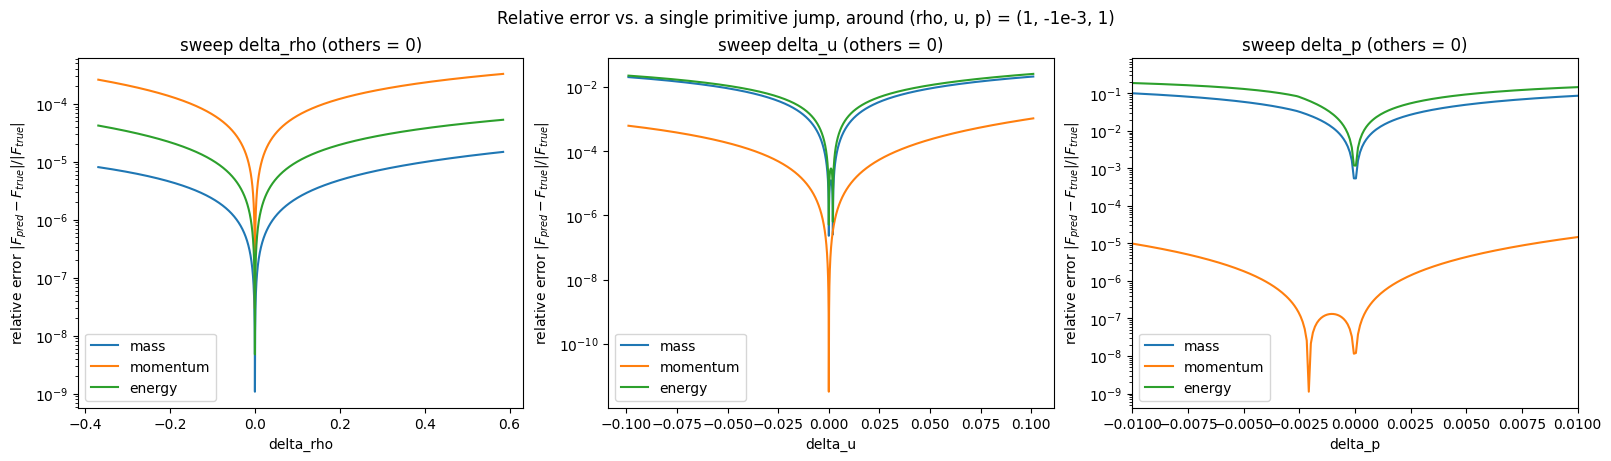

In [20]:
from physics import abs_flux_jacobian_from_primitive_state, flux_from_primitive_state

# 1D sweeps around the base state (rho, u, p) = (1, 0, 1): vary one jump at a
# time, holding the other two at zero. Left state is fixed at the base; the
# right state is base + delta in a single primitive variable.
t_fix = 0.5
N = 10000
eps = 1e-2

# log10 of the base state and per-variable right-state sweep ranges
log10_rho0, u0, log10_p0 = 0.0, -1e-3, 0.0
sweeps = {
    "delta_rho": dict(col=4, vals=jnp.linspace(-0.2, 0.2, N), log=True,  base=log10_rho0),
    "delta_u":   dict(col=5, vals=jnp.linspace(-0.1, 0.1, N), log=False, base=u0),
    "delta_p":   dict(col=6, vals=jnp.linspace(-0.2, 0.2, N), log=True,  base=log10_p0),
}

channel_labels = ("mass", "momentum", "energy")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for ax, (name, cfg) in zip(axes, sweeps.items()):
    # Base input: [t, log10_rhoL, uL, log10_pL, log10_rhoR, uR, log10_pR]
    base_row = jnp.array([t_fix, log10_rho0, u0, log10_p0, log10_rho0, u0, log10_p0])
    x = jnp.broadcast_to(base_row, (N, 7)).at[:, cfg["col"]].set(cfg["vals"])

    # Convert the swept right-state coordinate to a physical delta vs the base.
    if cfg["log"]:
        delta = 10.0 ** cfg["vals"] - 10.0 ** cfg["base"]
    else:
        delta = cfg["vals"] - cfg["base"]

    flux_true = jax.vmap(F_true)(x)
    
    flux_L = flux_from_primitive_state(10.0**x[...,1], x[...,2], 10.0**x[...,3]).T
    flux_R = flux_from_primitive_state(10.0**x[...,4], x[...,5], 10.0**x[...,6]).T
    flux_LR = 0.5 * (flux_L + flux_R)

    U_L = jnp.array([10.0**x[...,1], x[...,2], 10.0**x[...,3]]).T
    U_R = jnp.array([10.0**x[...,4], x[...,5], 10.0**x[...,6]]).T
    U_ave = 0.5 * (U_L + U_R)
    U_RL = U_R - U_L

    D = jax.vmap(abs_flux_jacobian_from_primitive_state)(U_ave[...,0], U_ave[...,1], U_ave[...,2])

    print('D.shape: ', D.shape)
    print('U_RL.shape: ', U_RL.shape)
    print('flux_LR.shape: ', flux_LR.shape)
    print('flux_true.shape: ', flux_true.shape)
    flux_D = jnp.einsum('nij,nj->ni', D, U_RL)

    print('flux_D.shape: ', flux_D.shape)


    flux_pred = flux_LR - 0.5 * flux_D

    rel = jnp.abs(flux_pred - flux_true) / (jnp.abs(flux_true) + eps)

    for i, ch in enumerate(channel_labels):
        ax.plot(jnp.asarray(delta), jnp.asarray(rel[:, i]), label=ch)
    ax.set_yscale("log")
    ax.set_xlabel(name)
    ax.set_ylabel(r"relative error $|F_{pred}-F_{true}|/|F_{true}|$")
    ax.set_title(f"sweep {name} (others = 0)")
    ax.legend()

axes[2].set(xlim=(-0.01, 0.01))

fig.suptitle("Relative error vs. a single primitive jump, around (rho, u, p) = (1, -1e-3, 1)")
plt.show()